## Cat-Dog Classifier

In [9]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, MaxPooling2D, Flatten, BatchNormalization, Conv2D

import matplotlib.pyplot as plt

In [2]:
# image data loading

train_ds = keras.utils.image_dataset_from_directory(
    directory='../datasets/Cat_Dog/',
    label_mode='int',
    labels='inferred',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset='training',
    seed=149
)

test_ds = keras.utils.image_dataset_from_directory(
    directory='../datasets/Cat_Dog/',
    label_mode='int',
    labels='inferred',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset='validation',
    seed=149
)

Found 24824 files belonging to 2 classes.
Using 19860 files for training.
Found 24824 files belonging to 2 classes.
Using 4964 files for validation.


In [3]:
# Normalize 

def normalize(img, label):
    # img = img/255.0
    img = tensorflow.cast(img/255.0, tensorflow.float32)
    return img, label

train_ds = train_ds.map(normalize)
test_ds = test_ds.map(normalize)

### CNN Model

In [4]:
model = Sequential()

model.add(Conv2D(6, input_shape=(256, 256, 3), kernel_size=(5, 5), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

model.add(Conv2D(16, kernel_size=(5, 5), activation='relu', padding='valid'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┓
┃                ┃ Output    ┃ Param ┃
┃ Layer (type)   ┃ Shape     ┃     # ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━┩
│ conv2d         │ (None,    │   456 │
│ (Conv2D)       │ 252, 252, │       │
│                │ 6)        │       │
├────────────────┼───────────┼───────┤
│ batch_normali… │ (None,    │    24 │
│ (BatchNormali… │ 252, 252, │       │
│                │ 6)        │       │
├────────────────┼───────────┼───────┤
│ max_pooling2d  │ (None,    │     0 │
│ (MaxPooling2D) │ 126, 126, │       │
│                │ 6)        │       │
├────────────────┼───────────┼───────┤
│ conv2d_1       │ (None,    │ 2,416 │
│ (Conv2D)       │ 122, 122, │       │
│                │ 16)       │       │
├────────────────┼───────────┼───────┤
│ batch_normali… │ (None,    │    64 │
│ (BatchNormali… │ 122, 122, │       │
│                │ 16)       │       │
├────────────────┼───────────┼───────┤
│ max_pooling2d… │ (None,    │     0 │
│ (MaxPooling2D) │ 61, 61,   │       │
│                │ 16)       │       │
├────────────────┼───────────┼───────┤
│ flatten        │ (None,    │     0 │
│ (Flatten)      │ 59536)    │       │
├────────────────┼───────────┼───────┤
│ dense (Dense)  │ (None,    │ 7,62… │
│                │ 128)      │       │
├────────────────┼───────────┼───────┤
│ dense_1        │ (None,    │ 10,8… │
│ (Dense)        │ 84)       │       │
├────────────────┼───────────┼───────┤
│ dense_2        │ (None, 1) │    85 │
│ (Dense)        │           │       │
└────────────────┴───────────┴───────┘

 Total params: 7,634,617 (29.12 MB)

 Trainable params: 7,634,573 (29.12 MB)

 Non-trainable params: 44 (176.00 B)

In [5]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [6]:
history = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10


D:\Deep Learning\dl\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


621/621 ━━━━━━━━━━━━━━━━━━━━ 393s 629ms/step - accuracy: 0.6197 - loss: 0.9878 - val_accuracy: 0.6487 - val_loss: 0.6139
Epoch 2/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 373s 600ms/step - accuracy: 0.7060 - loss: 0.5695 - val_accuracy: 0.6481 - val_loss: 1.2037
Epoch 3/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 366s 589ms/step - accuracy: 0.7634 - loss: 0.4981 - val_accuracy: 0.6499 - val_loss: 0.6996
Epoch 4/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 366s 589ms/step - accuracy: 0.8187 - loss: 0.3967 - val_accuracy: 0.6876 - val_loss: 0.7219
Epoch 5/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 376s 605ms/step - accuracy: 0.8715 - loss: 0.3029 - val_accuracy: 0.6563 - val_loss: 0.8348
Epoch 6/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 407s 653ms/step - accuracy: 0.9087 - loss: 0.2232 - val_accuracy: 0.6747 - val_loss: 1.0451
Epoch 7/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 371s 597ms/step - accuracy: 0.9331 - loss: 0.1774 - val_accuracy: 0.6813 - val_loss: 1.1961
Epoch 8/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 373s 599ms/step - accuracy: 0.9594 - loss: 0.11

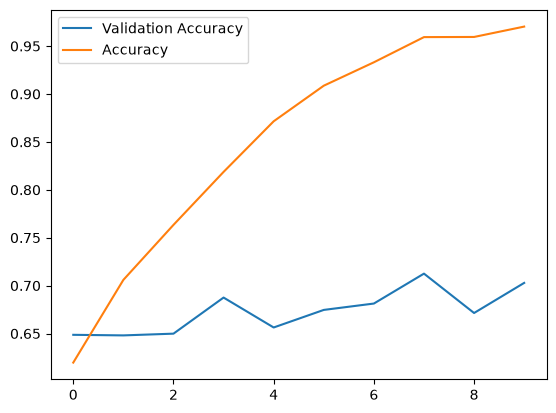

In [11]:
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.plot(history.history['accuracy'], label="Accuracy")

plt.legend()
plt.show()

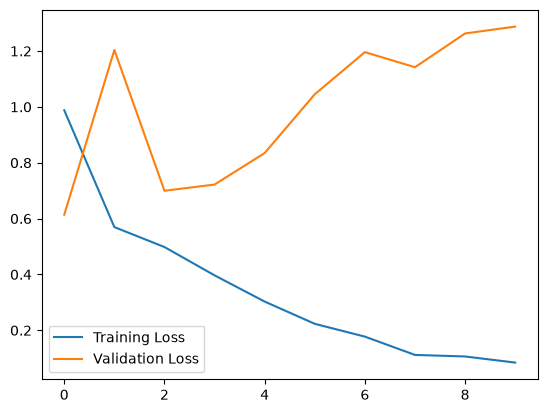

In [13]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.legend()
plt.show()